In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# Data Preparation

collection, cleaning and transformation of raw data into format suitable for ML model

In [3]:
import pandas as pd
df=pd.read_csv("lab4assignment-data.csv")
df.head(6)  #check if dataset is loaded

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [4]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


pytorch operates on tensor so the loaded data in pandas is converted to tensors

In [5]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

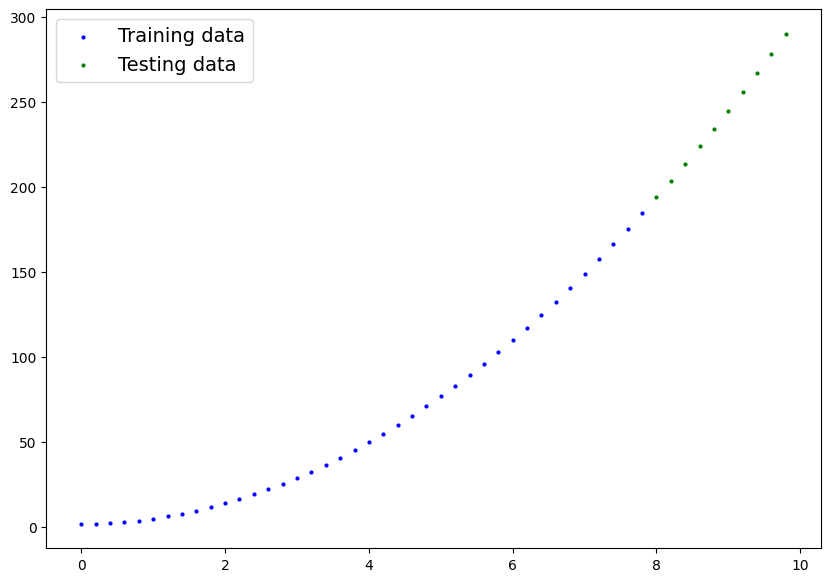

In [7]:
plot_predictions(X_train, y_train, X_test, y_test)

# 2) Algorithm Selection

Quadratic Regression is chosen.


It is used to model the reln betn independent variables and dependent variables when the relationship is nonlinear.

y=ax2+bx+c

where

a = coefficient of x^2

b = coefficient of x

c = intercept(constant )

In [8]:
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(torch.randn(1,
                                dtype=torch.float),
                                requires_grad=True)

        self.b = nn.Parameter(torch.randn(1,
                                dtype=torch.float),
                                requires_grad=True)

        self.c = nn.Parameter(torch.randn(1,
                                dtype=torch.float),
                                requires_grad=True)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [9]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = QuadraticRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [10]:
print(model_0.a.dtype)
print(model_0.b.dtype)

torch.float32
torch.float32


In [11]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

In [12]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


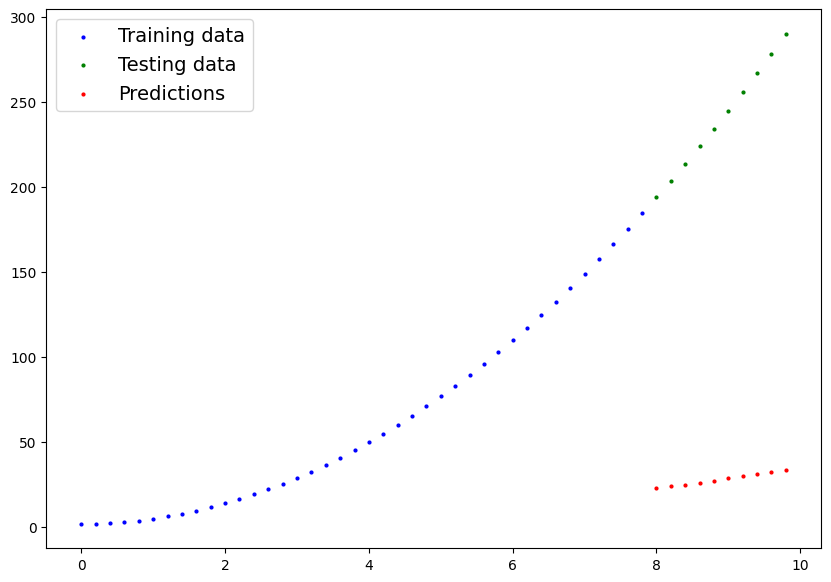

In [13]:
plot_predictions(predictions=y_preds)

# 3) Loss function selection

It measures difference betn actual values and the values that are predicted by the model.

MAE i.e Mean Absolute Error is chosen which calculates the average absolute diff betn predicted and actual values

MAE=n1​∑i=1n​∣yi​−y^​i​∣

In [14]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

optimizer updates model parameters to minimize loss function

SGD(Stochastic Gradient Descent) adjusts weight and bias values in a direction that reduces prediction error. It computes gradients using backpropagation and updates paramaters acc to learning rate

# 4) Model Training


process from which model learns patterns from training data


In [15]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967559814453125 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157402038574219 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925449132919312 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 
Epoch: 50 | MAE Train Loss: 0.45725950598716736 | MAE Test Loss: 15.107688903808594 
Epoch: 60 | MAE Train Loss: 2.150113582611084 | MAE Test Loss: 8.50035285949707 
Epoch: 70 | MAE Train Loss: 1.5265477895736694 | MAE Test Loss: 10.717729568481445 
Epoch: 80 | MAE Train Loss: 1.0148272514343262 | MAE Test Loss: 12.52308177947998 
Epoch: 90 | MAE Train Loss: 0.6227549910545349 | MAE Test Loss: 13.890657424926758 
Epoch: 100 | MAE Train Loss: 1.0679795742034912 | MAE Test Loss: 12.078683853149414 
Epoch: 110 | MAE Train Loss: 0.7058199644088745 | MAE Test Loss: 13.3368434906005

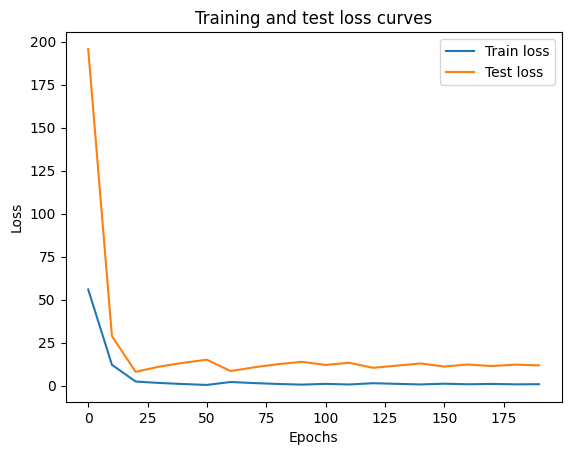

In [16]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [17]:
# Find our model's learned parameters
print("The model learned the following values for a,b and c:")
print(model_0.state_dict())

The model learned the following values for a,b and c:
OrderedDict({'a': tensor([2.8523]), 'b': tensor([0.8303]), 'c': tensor([0.7350])})


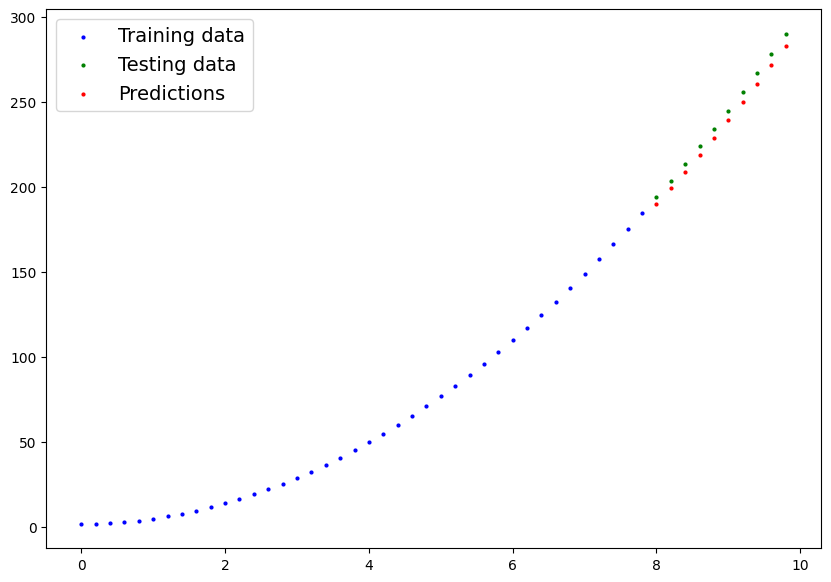

In [18]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

During evaluation, gradient calculations are disabled using torch.inference_mode() to improve efficiency. The trained model generates predictions for unseen data, and these predictions are compared with actual values to assess performance.

# Data 2

In [19]:
import pandas as pd
import torch

df = pd.read_csv("lab4assignment-data2.csv")
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [20]:
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


In [21]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

In [22]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

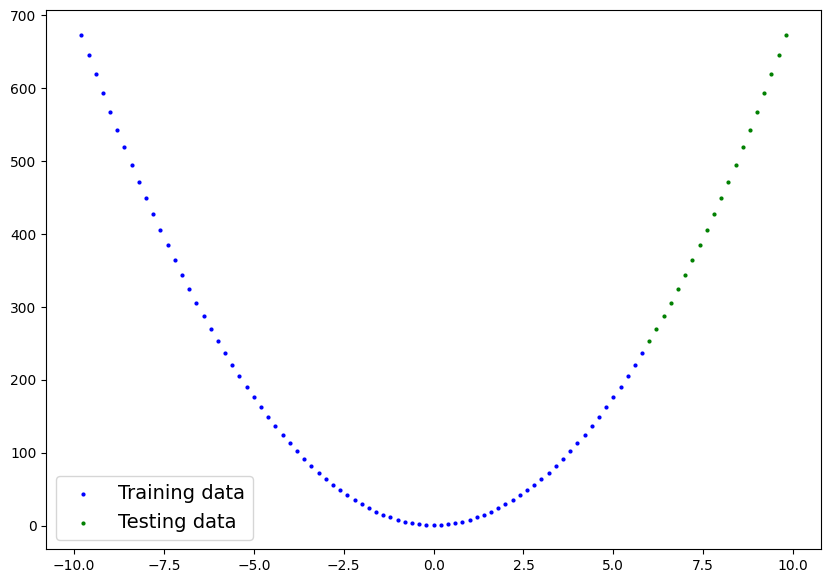

In [23]:
plot_predictions(X_train, y_train, X_test, y_test)

# 2) Algorithm selection

In [24]:
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(torch.randn(1,
                                dtype=torch.float),
                                requires_grad=True)

        self.b = nn.Parameter(torch.randn(1,
                                dtype=torch.float),
                                requires_grad=True)

        self.c = nn.Parameter(torch.randn(1,
                                dtype=torch.float),
                                requires_grad=True)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [25]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = QuadraticRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [26]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [27]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)


In [28]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789],
        [17.6340],
        [18.6159],
        [19.6248],
        [20.6606],
        [21.7234],
        [22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


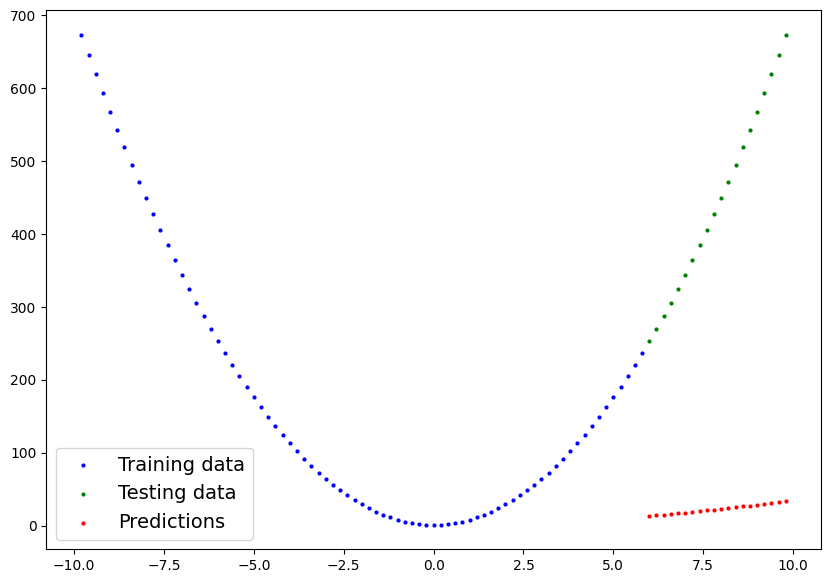

In [29]:
plot_predictions(predictions=y_preds)

# 3) Loss function selection

In [30]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

# 4) Model Training

In [31]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.2732391357422 | MAE Test Loss: 408.8077697753906 
Epoch: 10 | MAE Train Loss: 104.26924896240234 | MAE Test Loss: 252.2126007080078 
Epoch: 20 | MAE Train Loss: 42.265235900878906 | MAE Test Loss: 95.61738586425781 
Epoch: 30 | MAE Train Loss: 2.1109044551849365 | MAE Test Loss: 6.325655937194824 
Epoch: 40 | MAE Train Loss: 1.2364046573638916 | MAE Test Loss: 8.994148254394531 
Epoch: 50 | MAE Train Loss: 1.0613176822662354 | MAE Test Loss: 9.8119478225708 
Epoch: 60 | MAE Train Loss: 1.1207554340362549 | MAE Test Loss: 10.009692192077637 
Epoch: 70 | MAE Train Loss: 0.8819864988327026 | MAE Test Loss: 10.844189643859863 
Epoch: 80 | MAE Train Loss: 0.9476461410522461 | MAE Test Loss: 10.903528213500977 
Epoch: 90 | MAE Train Loss: 1.4739694595336914 | MAE Test Loss: 9.812562942504883 
Epoch: 100 | MAE Train Loss: 1.0053342580795288 | MAE Test Loss: 11.123374938964844 
Epoch: 110 | MAE Train Loss: 0.6294490098953247 | MAE Test Loss: 12.171618461608887 
E

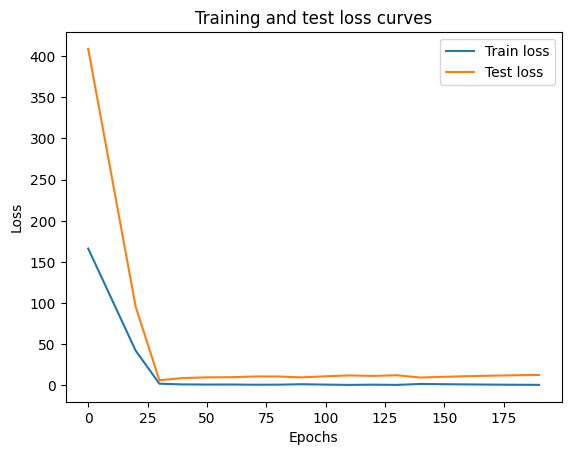

In [32]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [33]:
# Find our model's learned parameters
print("The model learned the following values for a, b and c:")
print(model_0.state_dict())

The model learned the following values for a, b and c:
OrderedDict({'a': tensor([6.9778]), 'b': tensor([-0.1103]), 'c': tensor([0.7917])})


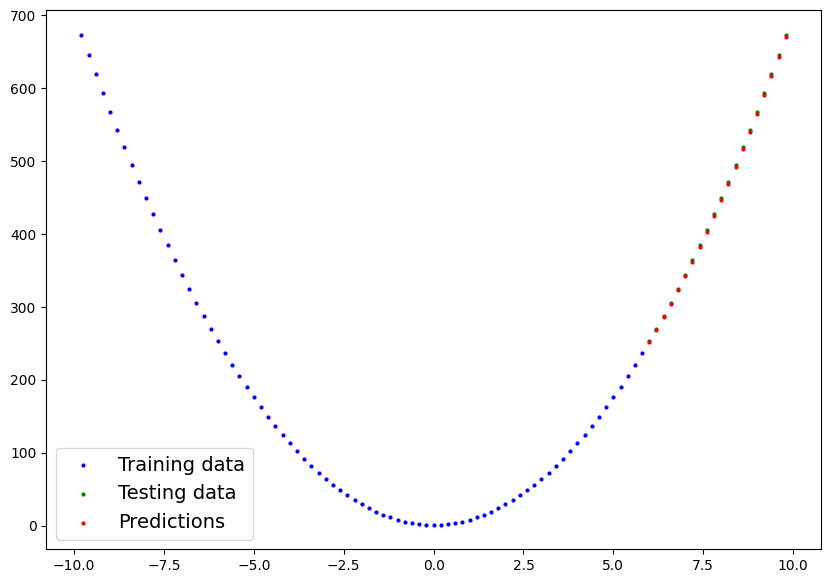

In [34]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Discussion

The linear regression model was implemented using PyTorch. The model learned relationship betn input and output data through training with MAE loss function and SGD optimizer. This experiment shows basic workflow of building, training and evaluating a regression model in PyTorch.

## Conclusion

This lab demonstrated successful implementation of linear regression using PyTorch. The model achieved predictiions that closely matched the actual values which was trained using MAE loss function and SGD optimizer. This indicates that model captures linear regression efficiently. 